# Preprocessing & Ekstraksi Fitur Berita Detik

Pipeline preprocessing: **case folding -> tokenisasi (buang tanda baca & angka) -> normalisasi bahasa tidak baku -> buang kata asing**, lalu **ekstraksi fitur**: Bag of Words (DTM frekuensi) dan **TF-IDF**. Keduanya disimpan dalam satu file `dtm_detik.xlsx` (2 sheet).

## Import Library

In [1]:
import pandas as pd
import re
from collections import Counter

print(f"pandas {pd.__version__} OK")

pandas 3.0.5 OK


## Load Data

In [2]:
df = pd.read_csv("detik_berita.csv", sep=";", dtype=str)
df.columns = [c.strip() for c in df.columns]
df["id"] = df["id"].str.strip()
df["isi_berita"] = df["isi_berita"].fillna("")
print(f"{len(df)} berita | kolom: {list(df.columns)}")
df.head()

200 berita | kolom: ['id', 'isi_berita', 'tema']


,id,isi_berita,tema
0,1,Harga emas Antam terus mengalami penurunan dan...,finance
1,2,"Perdana Menteri (PM) Singapura, Lawrence Wong,...",finance
2,3,Semua masyarakat akan memiliki rekening bank. ...,finance
3,4,"CEO Badan Pengelola Investasi (BPI) Danantara,...",finance
4,5,Jakarta - Kampoeng Mainan di Blok M Square men...,finance


## Kamus Bahasa Tidak Baku & Kata Asing

Kamus disusun berbasis data: kandidat kata diambil dari hasil scan frekuensi 200 artikel `detik_berita.csv`, lalu dikurasi manual. Kata serapan yang sudah baku KBBI (bank, data, investasi, skor, final, unit, program) serta nama orang/tempat/klub tetap dipertahankan. Scan diperketat pada tahap ini supaya Bag of Words (dan turunannya TF-IDF) sudah bersih dari kata asing.

In [3]:
KAMUS_TIDAK_BAKU = {
    "nggak": "tidak", "enggak": "tidak", "gak": "tidak", "kagak": "tidak",
    "udah": "sudah", "gitu": "begitu", "gini": "begini",
    "bikin": "membuat", "biarin": "biarkan", "cuma": "hanya",
    "aja": "saja", "tuh": "itu", "kayaknya": "sepertinya", "kayak": "seperti",
    "ngaco": "kacau", "banget": "sangat", "makin": "semakin",
    "dibilang": "dikatakan", "bilang": "berkata",
    "cuan": "untung", "karir": "karier",
    "ojol": "ojek", "detikers": "pembaca", "gede": "besar",
    "emang": "memang", "gimana": "bagaimana", "pakai": "memakai",
    "kalo": "kalau", "mesti": "harus", "dipindahin": "dipindahkan",
    "yg": "yang", "dgn": "dengan", "utk": "untuk", "spt": "seperti", "krn": "karena",
    "perkeonomian": "perekonomian", "pemeritah": "pemerintah", "menyetujul": "menyetujui",
    "sih": "", "kok": "", "deh": "", "dong": "", "lah": "", "toh": "", "loh": "", "mah": "",
    "kan": "", "nih": "",
}

KAMUS_ASING_SUBSTITUSI = {
    "import": "impor", "point": "poin", "tennis": "tenis",
    "elite": "elit", "standard": "standar",
}

KATA_ASING = {
    "a", "an", "and", "are", "as", "at", "be", "been", "but", "by", "can", "could",
    "do", "does", "did", "for", "from", "had", "has", "have", "he", "her", "his",
    "if", "in", "into", "is", "it", "its", "may", "might", "must", "not", "of", "on",
    "or", "she", "should", "so", "than", "that", "the", "their", "them", "there",
    "these", "they", "this", "those", "to", "was", "we", "were", "what", "when",
    "where", "which", "while", "who", "whom", "why", "will", "with", "would", "you",
    "your", "all", "any", "both", "each", "few", "more", "most", "other", "some",
    "such", "no", "own", "same", "too", "only", "just", "because", "until", "now",
    "very", "about", "after", "before", "between", "over", "under", "again", "further",
    "then", "once", "here", "men", "him", "us", "com", "www",
    "games", "champions", "league", "world", "race", "run", "set", "team", "start",
    "beach", "sport", "sports", "event", "fc", "super", "top", "pre", "center",
    "international", "approved", "online", "offline", "business", "price", "pricing",
    "market", "marketplace", "asset", "leveraging", "buy", "buyback", "corporate",
    "group", "location", "single", "streamlining", "commerce", "national", "investment",
    "artificial", "intelligence", "existing", "cost", "training", "tax", "village",
    "fame", "harmony", "marketing", "host", "buying", "panic", "tower", "fraud",
    "mission", "sprint", "tour", "time", "step", "running", "runner", "fun",
    "throwdown", "endurance", "fitness", "lap", "series", "matchday", "assist",
    "match", "striker", "brace", "bronze", "venue", "premier", "grand", "prix",
    "ballon", "championship", "injury", "crash", "mixed", "tiebreak", "blunder",
    "power", "brand", "interim", "service", "batch", "smart", "education", "visionary",
    "lab", "partner", "plus", "vehicle", "rating", "supplier", "reseller", "action",
    "outdoor", "wedding", "shop", "social", "beneficiary", "committee", "development",
    "core", "public", "expose", "founder", "direct", "management", "monitoring",
    "under", "invoicing", "work", "forwarder", "tech", "activ", "entertainment",
    "out", "travel", "one", "wave", "vertical", "hours", "grandstand", "rider",
    "grid", "titel", "tag", "level", "spot",
    "activation", "agreement", "airport", "athletic", "association", "authority",
    "autosports", "autographs", "back", "baby", "backup", "beginning",
    "water", "fair", "speed", "science", "plan", "station", "stretch", "animal",
    "money", "window", "officer", "figure", "income", "basic", "supply", "capital",
    "special", "road", "stop", "live", "enjoy", "effect", "prize", "support",
    "silver", "profit", "general", "due", "movement", "make", "beyond", "family",
    "human", "stand", "agency", "term", "ring", "return", "value", "music",
    "happy", "sale", "fire", "kick", "move", "wild", "forward", "stage", "length",
    "nice", "end", "customer", "stay", "miss", "follow", "class", "share", "form",
    "test", "home", "serve", "purpose", "law", "fresh", "play",
    "gathering", "tournament", "communication", "voting", "workstation",
    "submission", "fulfilling", "junction", "construction", "forwarding",
    "qualifying", "ratings", "confidence", "reflection", "governance", "lifting",
    "clearance", "spending", "opening", "sourcing", "floating", "motion",
    "transportation", "calling", "foundation", "sharing", "engagement", "funding",
    "excellence", "trending", "suretyship", "leading", "promotion", "meaning",
    "warning", "treatment", "notification", "mapping", "endorsement", "enforcement",
    "dimension", "operation", "procurement", "leadership", "purchasing",
    "livestreaming", "grooming", "engineering", "reference", "overloading",
    "recording", "collection", "distribution", "handling", "bombing", "wellness",
}

print(f"KAMUS_TIDAK_BAKU: {len(KAMUS_TIDAK_BAKU)}")
print(f"KAMUS_ASING_SUBSTITUSI: {len(KAMUS_ASING_SUBSTITUSI)}")
print(f"KATA_ASING: {len(KATA_ASING)} kata asing")

KAMUS_TIDAK_BAKU: 48
KAMUS_ASING_SUBSTITUSI: 5
KATA_ASING: 368 kata asing


## Fungsi Preprocessing

1. **Case folding** - ubah semua huruf jadi lowercase.
2. **Tokenisasi** - ambil token huruf saja `[a-z]+`; tanda baca, angka, dan simbol otomatis terpisah lalu dibuang. Token 1 huruf (Seri A/B, sisa romawi) dibuang.
3. **Normalisasi tidak baku** - kata tidak baku/partikel diganti bentuk baku (atau dibuang bila tidak punya padanan: `sih`, `kok`, `deh`, `lah`, dst.).
4. **Buang kata asing** - kata bahasa asing (English function words + istilah asing umum) dibuang; kata yang punya ejaan Indonesia (`import->impor`, `point->poin`) dinormalkan dulu.

In [4]:
def bersihkan(teks):
    teks = teks.casefold()
    token = re.findall(r"[a-z\u00e0-\u00ff]+", teks)
    token = [t for t in token if len(t) > 1]
    token = [KAMUS_TIDAK_BAKU.get(t, t) for t in token]
    token = [KAMUS_ASING_SUBSTITUSI.get(t, t) for t in token]
    token = [t for t in token if t and t not in KATA_ASING]
    return token

## Main - Preprocessing 200 Berita

In [5]:
df["tok"] = df["isi_berita"].apply(bersihkan)
df["teks_bersih"] = df["tok"].apply(" ".join)

df[["id", "isi_berita", "teks_bersih"]].head(3)

,id,isi_berita,teks_bersih
0,1,Harga emas Antam terus mengalami penurunan dan...,harga emas antam terus mengalami penurunan dan...
1,2,"Perdana Menteri (PM) Singapura, Lawrence Wong,...",perdana menteri pm singapura lawrence wong ber...
2,3,Semua masyarakat akan memiliki rekening bank. ...,semua masyarakat akan memiliki rekening bank p...


## Ekstraksi Fitur - Bag of Words

Setiap dokumen dihitung `Counter`-nya, lalu diubah jadi tabel **2D/DTM**: baris = id berita, kolom = seluruh kata unik, isi = frekuensi kemunculan kata pada dokumen itu. Hasilnya ditulis ke sheet **"Bag of Words"** pada `dtm_detik.xlsx` (digabung dengan hasil TF-IDF).

In [6]:
counts = df["tok"].apply(Counter)
all_words = sorted(set(w for c in counts for w in c))

mrow = []
for c in counts:
    mrow.append({w: c[w] for w in all_words if w in c})

mtx = pd.DataFrame(mrow).fillna(0).astype(int)
if "id" in mtx.columns:
    mtx = mtx.rename(columns={"id": "kata_id"})
mtx.insert(0, "id", df["id"].astype(str))

print(f"DTM Bag of Words: {mtx.shape[0]} dokumen x {mtx.shape[1]} kolom (id + {mtx.shape[1]-1} kata unik) -> sheet 'Bag of Words' di dtm_detik.xlsx")
mtx.head()

DTM Bag of Words: 200 dokumen x 7142 kolom (id + 7141 kata unik) -> sheet 'Bag of Words' di dtm_detik.xlsx


,id,adalah,akan,akhir,ambruk,anda,angka,antam,batangan,berada,...,fernandez,kesadaran,manuver,pecco,rasakan,teranyar,terendah,terjatuh,untungnya,warnai
0,1,1,2,1,1,1,1,9,1,4,...,0,0,0,0,0,0,0,0,0,0
1,2,1,7,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Statistik Vocab (Bag of Words)

In [7]:
raw_all = re.findall(r"[a-z\u00e0-\u00ff]+", " ".join(df["isi_berita"]).casefold())
print(f"Token mentah  : {len(raw_all):>7}")
print(f"Token bersih  : {sum(len(t) for t in df['tok']):>7}")
print(f"Kata unik mentah: {len(set(raw_all)):>7}")
print(f"Kata unik bersih: {len(all_words):>7}")

top10 = mtx.drop(columns="id").sum().sort_values(ascending=False).head(10)
print()
print("Top-10 kata paling sering:")
print(top10)

Token mentah  :   60357
Token bersih  :   58543
Kata unik mentah:    7489
Kata unik bersih:    7141

Top-10 kata paling sering:
yang      1336
di        1238
dan       1167
ini        674
untuk      625
dari       608
dengan     590
dalam      491
juga       445
itu        431
dtype: int64


## TF-IDF

Setelah BOW, berita direpresentasikan dengan **TF-IDF** (Term Frequency - Inverse Document Frequency) dari data terbaru Bag of Words.

- **TF** (term frequency) : frekuensi kata di dalam sebuah dokumen.
- **IDF** (inverse document frequency) : logaritma kebalikan dari proporsi dokumen yang memuat kata -> kata yang muncul di banyak dokumen mendapat bobot kecil, kata yang langka mendapat bobot besar.

Bobotnya `TF x IDF`. Dihitung dengan `TfidfVectorizer` sklearn (smooth_idf + normalisasi L2, setara lib standar) dari token bersih hasil preprocessing yang sama. Kata fungsi bahasa Indonesia (yang, di, dan, ...) dibuang dulu via `STOPWORDS_ID` karena tidak informatif.

In [8]:
STOPWORDS_ID = {
    "yang", "dan", "di", "ke", "dari", "pada", "itu", "ini", "juga", "untuk",
    "dengan", "akan", "adalah", "ialah", "oleh", "karena", "agar", "sebagai",
    "para", "dalam", "serta", "atau", "masih", "sudah", "belum", "tidak",
    "bukan", "bisa", "dapat", "lebih", "saat", "ketika", "setelah", "sebelum",
    "selama", "melalui", "antara", "hingga", "kemudian", "lantas", "merupakan",
    "namun", "tetapi", "tapi", "terdapat", "ada", "adanya", "yaitu", "yakni",
    "terkait", "misalnya", "maupun", "seperti", "jika", "kalau", "maka", "harus",
    "hendak", "sangat", "paling", "semua", "setiap", "beberapa", "saya", "anda",
    "kami", "kita", "mereka", "dia", "ia", "kepada", "bagi", "pun",
    "saja", "mungkin", "lagi", "tersebut", "adapun", "beserta",
}

stop_kemunculan = Counter(x for toks in df["tok"] for x in toks if x in STOPWORDS_ID)
tbl_stop = pd.DataFrame(
    stop_kemunculan.items(),
    columns=["kata", "kemunculan"],
).sort_values("kemunculan", ascending=False).reset_index(drop=True)
tbl_stop

,kata,kemunculan
0,yang,1336
1,di,1238
2,dan,1167
3,ini,674
4,untuk,625
...,...,...
73,terdapat,14
74,misalnya,5
75,lantas,3
76,hendak,3


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b\w\w+\b",
    stop_words=sorted(STOPWORDS_ID),
)
X = tfidf_vec.fit_transform(df["teks_bersih"])

print(f"Matrix TF-IDF : {X.shape[0]} dokumen x {X.shape[1]} kata (setelah buang stopword BI)")
print(f"Nilai bukan nol: {100 * (X.nnz / (X.shape[0] * X.shape[1])):.2f}% (sparse)")

Matrix TF-IDF : 200 dokumen x 7063 kata (setelah buang stopword BI)
Nilai bukan nol: 1.94% (sparse)


In [10]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=tfidf_vec.get_feature_names_out(),
).round(4)
if "id" in tfidf_df.columns:
    tfidf_df = tfidf_df.rename(columns={"id": "kata_id"})
tfidf_df.insert(0, "id", df["id"].astype(str))
tfidf_df.head()

,id,aam,aan,abadi,abal,abang,abdukhodir,abdul,abdullah,aberdeen,...,zhang,zigmars,zlatan,zona,zoom,zulfikar,zulhas,zulkifli,zurich,álvarez
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Statistik TF-IDF

In [11]:
kata = tfidf_vec.get_feature_names_out()
idf = pd.Series(tfidf_vec.idf_, index=kata)

print("Kata dengan IDF tertinggi (paling khas di korpus):")
print(idf.sort_values(ascending=False).head(10))

print("\nKata dengan IDF terendah (paling umum):")
print(idf.sort_values(ascending=True).head(10))

print("\nTop-5 bobot TF-IDF per dokumen contoh:")
for i in range(3):
    row = tfidf_df.drop(columns="id").iloc[i]
    print(f"\nID {df['id'].iloc[i]}:")
    print(row.sort_values(ascending=False).head(5))

Kata dengan IDF tertinggi (paling khas di korpus):
aberdeen      5.610158
álvarez       5.610158
aam           5.610158
aan           5.610158
abadi         5.610158
abal          5.610158
abang         5.610158
abdukhodir    5.610158
zigmars       5.610158
zlatan        5.610158
dtype: float64

Kata dengan IDF terendah (paling umum):
menjadi      1.567106
tahun        1.781516
indonesia    1.792445
satu         1.803495
hanya        1.860654
jadi         1.860654
ujar         1.908856
secara       1.933857
rabu         2.012845
video        2.012845
dtype: float64

Top-5 bobot TF-IDF per dokumen contoh:

ID 1:
gram     0.6200
emas     0.5426
harga    0.3824
antam    0.2536
rp       0.2461
Name: 0, dtype: float64

ID 2:
gaji             0.4934
wong             0.3107
pm               0.2955
singapura        0.2590
menyumbangkan    0.1645
Name: 1, dtype: float64

ID 3:
rekening      0.3765
airlangga     0.3196
kira          0.3098
apbn          0.2397
masyarakat    0.1865
Name: 2, dtype

## Reduksi Dimensi - PCA

### Langkah 1 - Pertahankan variance >= 95%

Matriks TF-IDF punya **7.063 kolom kata** (sangat lebar dan sparse). Reduksi pertama memakai PCA untuk menyimpan komponen sampai total variance terkumpul **>= 95%**.

- `PCA(n_components=0.95)` memilih sendiri jumlah kolom yang dibutuhkan untuk mencapai ambang itu - jumlahnya baru diketahui setelah kode di bawah dijalankan.
- `explained_variance_ratio_` menunjukkan proporsi informasi yang ditangkap tiap komponen.
- Hasil PCA bukan kolom kata lagi, melainkan **principal component**: kombinasi linier dari seluruh kolom kata TF-IDF.

In [12]:
X_tfidf = tfidf_df.drop(columns="id").to_numpy()
print("Matriks input PCA:", X_tfidf.shape)

Matriks input PCA: (200, 7063)


In [13]:
from sklearn.decomposition import PCA
pca_var = PCA(n_components=0.95, random_state=42)
X_low = pca_var.fit_transform(X_tfidf)

print("Sebelum (TF-IDF asli)   :", X_tfidf.shape)
print("Sesudah (PCA 95%)       :", X_low.shape)
print("Jumlah komponen dipilih :", pca_var.n_components_)
print("Total variance ditangkap: {:.2f}%".format(pca_var.explained_variance_ratio_.sum() * 100))

Sebelum (TF-IDF asli)   : (200, 7063)
Sesudah (PCA 95%)       : (200, 169)
Jumlah komponen dipilih : 169
Total variance ditangkap: 95.03%


In [14]:
import pandas as pd

# Tampilkan matriks hasil reduksi sebagai tabel
X_low_df = pd.DataFrame(X_low, columns=[f"PC{i + 1}" for i in range(X_low.shape[1])])
X_low_df.insert(0, "id", df["id"].astype(str))
print("Ukuran matriks tereduksi:", X_low_df.shape)
X_low_df.head()


Ukuran matriks tereduksi: (200, 170)


,id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC160,PC161,PC162,PC163,PC164,PC165,PC166,PC167,PC168,PC169
0,1,0.070496,-0.067612,-0.073233,0.008429,0.000285,-0.042209,-0.009882,0.198657,0.090578,...,-0.003116,0.025859,0.061726,0.031649,0.002077,0.055614,0.143353,0.045036,-0.017588,0.033296
1,2,0.064971,-0.045809,-0.042766,0.006199,-0.021568,-0.024853,-0.008091,0.071894,0.012955,...,-0.023290,0.034470,0.012761,-0.002211,0.002592,0.015493,-0.013838,0.012577,0.000843,-0.004172
2,3,0.394428,0.378229,0.231852,0.117999,-0.170445,0.052484,0.007270,0.034071,0.019426,...,0.024990,-0.000787,-0.018346,0.016456,0.021677,-0.018534,0.023291,-0.050060,-0.011973,-0.047943
3,4,0.404446,0.421979,0.274761,0.234078,-0.279931,0.070487,-0.020129,-0.043574,0.025504,...,-0.011644,-0.007181,0.003332,-0.008580,0.009904,-0.018400,0.011085,-0.035997,-0.028625,-0.015287
4,5,0.001040,-0.061738,-0.052059,-0.011983,-0.056981,0.004080,0.005591,-0.011264,-0.041397,...,0.002525,-0.022353,-0.015588,0.016858,-0.002304,0.002811,-0.004687,-0.011931,0.008162,-0.007872


### Langkah 2 - Visualisasi Hasil (Scatter Plot PCA)

Scatter plot butuh data 2 dimensi, jadi yang dipakai adalah **2 komponen teratas** dari hasil langkah 1: **PC1** (sumbu-X) dan **PC2** (sumbu-Y). Gambar berikut menampilkan sebaran 200 dokumen:

- Tiap titik = 1 berita; label angka = id dokumen (10 titik pertama diberi label).
- Titik yang **berdekatan** berarti kedua berita punya pola kata (TF-IDF) serupa; titik yang **jauh** berarti topiknya berbeda.
- Ruang 2D ini hanya mewakili ~4.32% total variance - cukup untuk melihat sebaran kasar, bukan seluruh informasi 7.063 kolom (95% sisanya sudah ditahan di 169 komponen langkah 1).


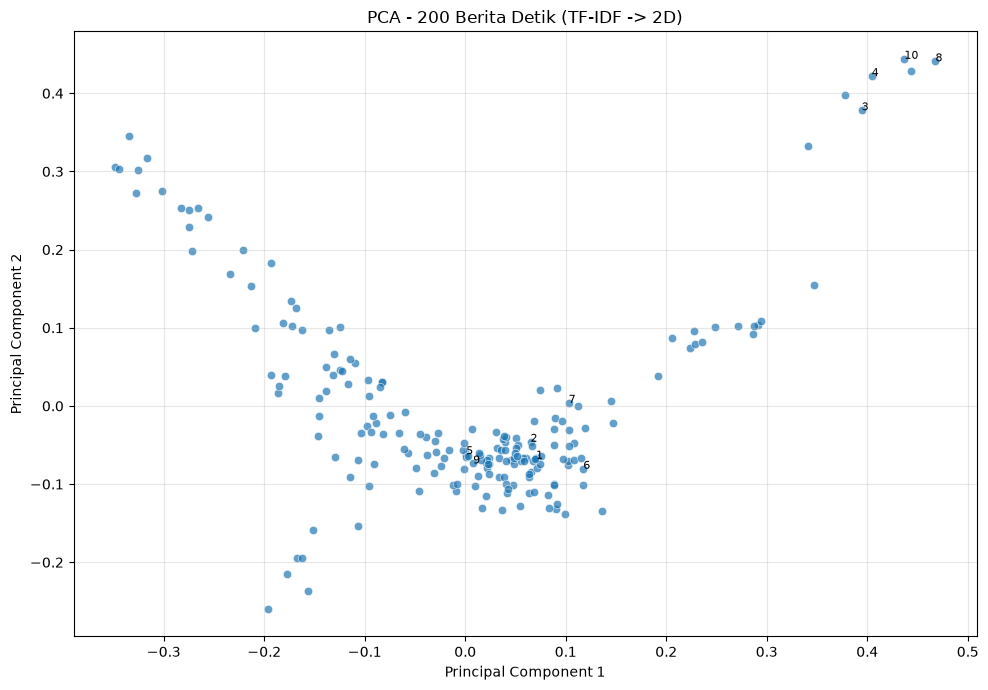

In [15]:
import matplotlib.pyplot as plt

pca_df = pd.DataFrame(X_low[:, :2], columns=["PC1", "PC2"])
pca_df.insert(0, "id", df["id"].astype(str))

plt.figure(figsize=(10, 7))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7, edgecolors="w", linewidth=0.5)

for i in range(min(10, len(pca_df))):
    plt.annotate(pca_df["id"].iloc[i], (pca_df["PC1"].iloc[i], pca_df["PC2"].iloc[i]), fontsize=8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 200 Berita Detik (TF-IDF -> 2D)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
# Simpan hasil ekstraksi fitur ke satu file Excel (3 sheet)
import pandas as pd

with pd.ExcelWriter("tugaspreprocessing.xlsx", engine="openpyxl") as writer:
    mtx.to_excel(writer, sheet_name="Bag of Words", index=False)
    tfidf_df.to_excel(writer, sheet_name="TF-IDF", index=False)
    pca_df.to_excel(writer, sheet_name="PCA", index=False)

print("Output tersimpan: tugaspreprocessing.xlsx (3 sheet: Bag of Words, TF-IDF, PCA)")

Output tersimpan: tugaspreprocessing.xlsx (3 sheet: Bag of Words, TF-IDF, PCA)
